In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data 
ticker = "^NSEI" 
data = yf.download(ticker, start="2015-01-01", end="2026-01-01")

# 2. Feature Engineering
# Log Returns (Stationary data is essential for ML)
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# Range (High-Low spread) - measures daily volatility
data['Range'] = (data['High'] - data['Low']) / data['Close']

# Rolling Volatility (20-day window)
data['Volatility'] = data['Returns'].rolling(window=20).std()

# Drop NaNs created by rolling windows
data.dropna(inplace=True)

print(f"Data Prepared: {data.shape[0]} rows")
data[['Close', 'Returns', 'Volatility']].tail()

[*********************100%***********************]  1 of 1 completed

Data Prepared: 2688 rows


Price,Close,Returns,Volatility
Ticker,^NSEI,,
Date,,,
2025-12-24,26142.099609,-0.001340,0.004497
2025-12-26,26042.300781,-0.003825,0.004570
2025-12-29,25942.099609,-0.003855,0.004637
2025-12-30,25938.849609,-0.000125,0.004636
2025-12-31,26129.599609,0.007327,0.004786


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Select features for the model
features = ['Returns', 'Range', 'Volatility']
X = data[features].values

# 2. Scaling (Essential for Distance-based and Variance-based models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA 
# We reduce 3 features down to 2 Principal Components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Store results back in dataframe for plotting later
data['PCA1'] = X_pca[:, 0]
data['PCA2'] = X_pca[:, 1]

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print("PCA completed. You now have 2 components representing the market state.")

Explained Variance Ratio: [0.52519454 0.33513731]
PCA completed. You now have 2 components representing the market state.


In [3]:
from sklearn.mixture import GaussianMixture

# 1. Initialize the EM Algorithm
# We choose n_components=2 to represent two primary market regimes
em_model = GaussianMixture(n_components=2, covariance_type='full', random_state=42)

# 2. Fit the model on our PCA-reduced data
data['Regime'] = em_model.fit_predict(X_pca)

# 3. Quick check: Look at the mean volatility per regime to identify them
regime_stats = data.groupby('Regime')['Volatility'].mean()
print("Average Volatility per Regime:")
print(regime_stats)

# Identify which regime is 'High Volatility' for the next step
high_vol_regime = regime_stats.idxmax()
print(f"\nRegime {high_vol_regime} is likely the 'Market Stress' or 'Bear' regime.")

Average Volatility per Regime:
Regime
0    0.007994
1    0.018356
Name: Volatility, dtype: float64

Regime 1 is likely the 'Market Stress' or 'Bear' regime.


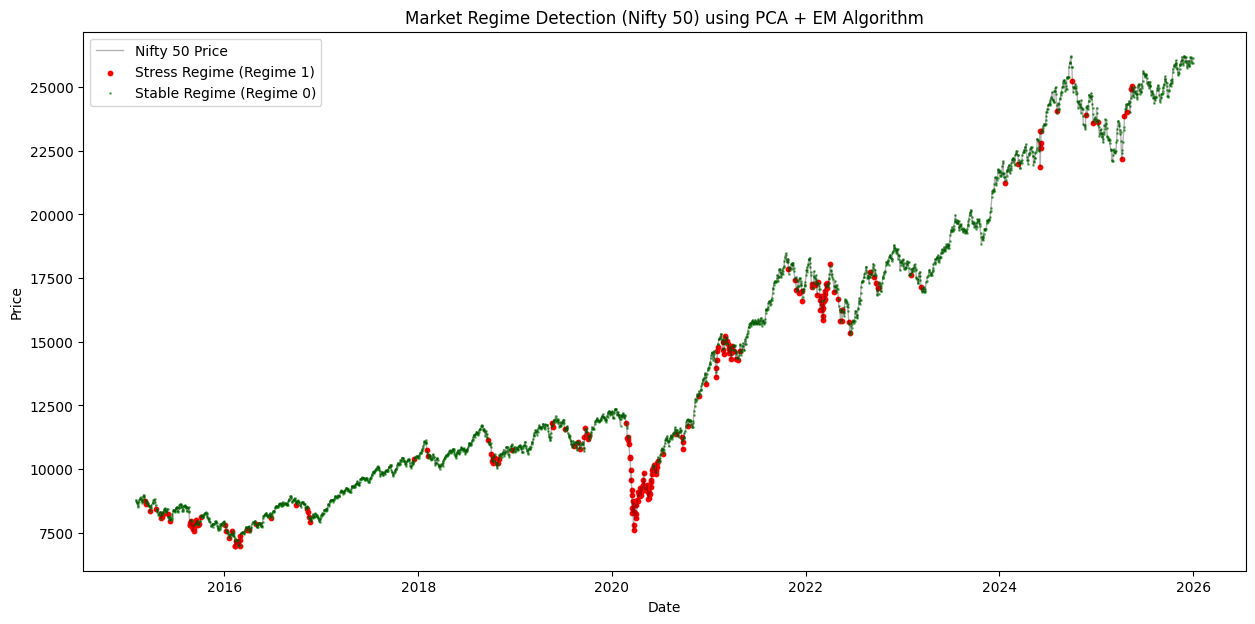

Regime Distribution:
Regime
0    91.517857
1     8.482143
Name: proportion, dtype: float64


In [4]:
# 1. Visualization of Regimes on the Nifty 50 Price Chart
plt.figure(figsize=(15, 7))

# Plot the Close price
plt.plot(data.index, data['Close'], color='black', lw=1, label='Nifty 50 Price', alpha=0.3)

# Highlight Regime 1 (High Volatility/Stress)
stress_days = data[data['Regime'] == high_vol_regime]
plt.scatter(stress_days.index, stress_days['Close'], color='red', s=10, label='Stress Regime (Regime 1)')

# Highlight Regime 0 (Low Volatility/Stable)
stable_regime = 1 if high_vol_regime == 0 else 0
stable_days = data[data['Regime'] == stable_regime]
plt.scatter(stable_days.index, stable_days['Close'], color='green', s=1, label='Stable Regime (Regime 0)', alpha=0.5)

plt.title('Market Regime Detection (Nifty 50) using PCA + EM Algorithm')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# 2. Output some Summary Statistics
print("Regime Distribution:")
print(data['Regime'].value_counts(normalize=True) * 100)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 1. Prepare Data for Supervised Learning
# Features: Scaled indicators, Target: The EM-generated Regimes
y = data['Regime']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Support Vector Machine
# Using an RBF kernel to handle the non-linear nature of market data
svm_model = SVC(kernel='rbf', C=1.0)
svm_model.fit(X_train, y_train)

# 3. Performance Measures
y_pred = svm_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report (Precision/Recall/F1):")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[491   0]
 [  1  46]]

Classification Report (Precision/Recall/F1):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       491
           1       1.00      0.98      0.99        47

    accuracy                           1.00       538
   macro avg       1.00      0.99      0.99       538
weighted avg       1.00      1.00      1.00       538



In [7]:
import os
import joblib

# 1. Create the 'models' directory if it doesn't exist
folder_name = "models"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Created directory: {folder_name}")

# 2. Define file paths
scaler_path = os.path.join(folder_name, "market_scaler.pkl")
pca_path = os.path.join(folder_name, "market_pca.pkl")
svm_path = os.path.join(folder_name, "market_svm.pkl")

# 3. Export the trained objects
joblib.dump(scaler, scaler_path)
joblib.dump(pca, pca_path)
joblib.dump(svm_model, svm_path)

print("--- Export Complete ---")
print(f"Saved Preprocessing Scaler to: {scaler_path}")
print(f"Saved PCA Transformer to: {pca_path}")
print(f"Saved SVM Classifier to: {svm_path}")

Created directory: models
--- Export Complete ---
Saved Preprocessing Scaler to: models/market_scaler.pkl
Saved PCA Transformer to: models/market_pca.pkl
Saved SVM Classifier to: models/market_svm.pkl
